In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [77]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data (1).zip


In [78]:
import zipfile

with zipfile.ZipFile("data.zip", 'r') as zip_ref:
    zip_ref.extractall("models")

In [79]:
df = pd.read_pickle("models/data/2018-04-01.pkl")

print(df.head())
print(df.columns)
print(df.shape)
print(df.info())

   TRANSACTION_ID         TX_DATETIME CUSTOMER_ID TERMINAL_ID  TX_AMOUNT  \
0               0 2018-04-01 00:00:31         596        3156      57.16   
1               1 2018-04-01 00:02:10        4961        3412      81.51   
2               2 2018-04-01 00:07:56           2        1365     146.00   
3               3 2018-04-01 00:09:29        4128        8737      64.49   
4               4 2018-04-01 00:10:34         927        9906      50.99   

  TX_TIME_SECONDS TX_TIME_DAYS  TX_FRAUD  TX_FRAUD_SCENARIO  
0              31            0         0                  0  
1             130            0         0                  0  
2             476            0         0                  0  
3             569            0         0                  0  
4             634            0         0                  0  
Index(['TRANSACTION_ID', 'TX_DATETIME', 'CUSTOMER_ID', 'TERMINAL_ID',
       'TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS', 'TX_FRAUD',
       'TX_FRAUD_SCENARIO'],
     

In [80]:
files = glob.glob("models/data/*.pkl")

df_list = []

for file in files:
    temp = pd.read_pickle(file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print(df.shape)

(1754155, 9)


In [81]:
df.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,1514078,2018-09-06 00:00:40,2913,8687,26.26,13651240,158,0,0
1,1514079,2018-09-06 00:01:13,3819,2838,56.40,13651273,158,0,0
2,1514080,2018-09-06 00:02:06,129,420,44.62,13651326,158,0,0
3,1514081,2018-09-06 00:02:41,3070,6498,19.87,13651361,158,0,0
4,1514082,2018-09-06 00:02:45,3505,5885,50.77,13651365,158,0,0


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   TRANSACTION_ID     int64         
 1   TX_DATETIME        datetime64[ns]
 2   CUSTOMER_ID        object        
 3   TERMINAL_ID        object        
 4   TX_AMOUNT          float64       
 5   TX_TIME_SECONDS    object        
 6   TX_TIME_DAYS       object        
 7   TX_FRAUD           int64         
 8   TX_FRAUD_SCENARIO  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 120.4+ MB


In [83]:
df.isnull().sum()

,0
TRANSACTION_ID,0
TX_DATETIME,0
CUSTOMER_ID,0
TERMINAL_ID,0
TX_AMOUNT,0
TX_TIME_SECONDS,0
TX_TIME_DAYS,0
TX_FRAUD,0
TX_FRAUD_SCENARIO,0


In [93]:
df.duplicated().sum()

np.int64(0)

In [95]:
df = df.drop(["TRANSACTION_ID","TX_DATETIME"], axis=1, errors='ignore')

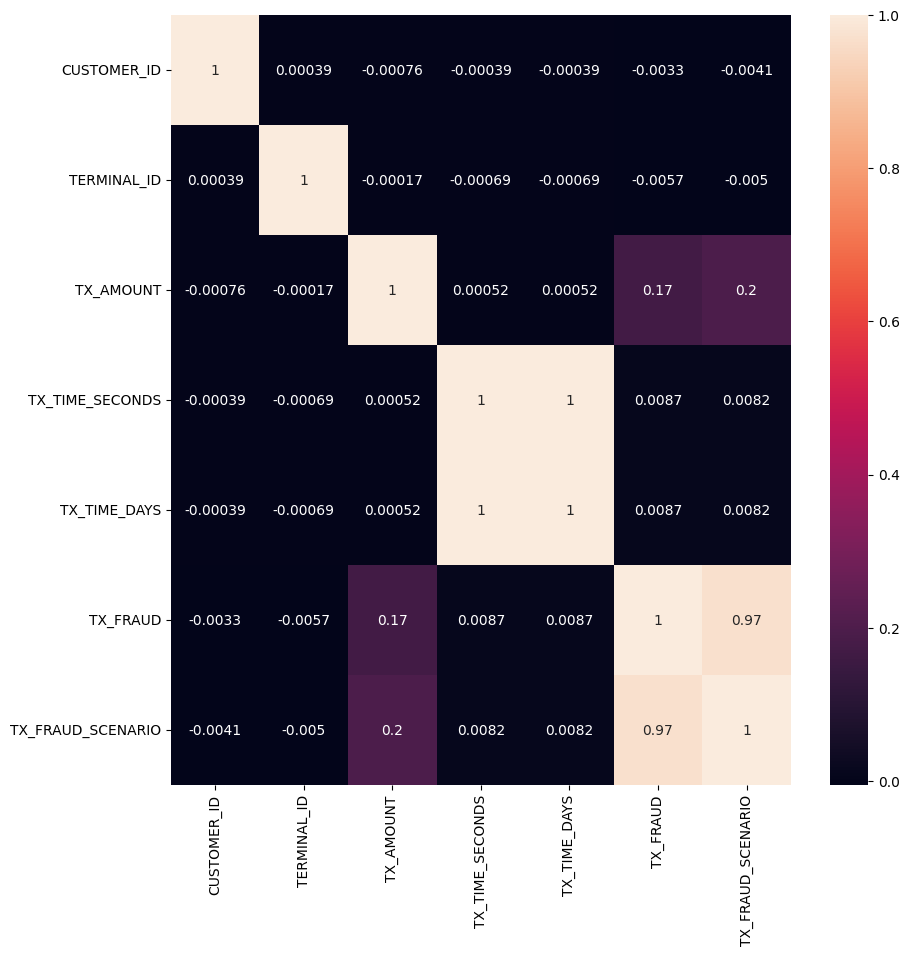

In [96]:
corrmat = df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(10,10))
g=sns.heatmap(df[top_corr_features].corr(),annot=True)

Model Training

In [97]:
print(df.columns.tolist())

['CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS', 'TX_FRAUD', 'TX_FRAUD_SCENARIO']


In [100]:
x = df.drop(["TX_FRAUD","TX_FRAUD_SCENARIO"], axis=1)
y = df["TX_FRAUD"]

In [101]:
x.shape


(1754155, 5)

In [102]:

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [103]:
print(x_train.shape)
print(x_test.shape)

(1403324, 5)
(350831, 5)


In [104]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [105]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [106]:
x_train.head(1)

,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS
1741849,739,3391,148.25,4633971,53


In [109]:
sample = pd.DataFrame([
    {
        'CUSTOMER_ID': 1111,
        'TERMINAL_ID': 4567,
        'TX_AMOUNT': 220.25,
        'TX_TIME_SECONDS': 4833973,
        'TX_TIME_DAYS': 60,
    }
])

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Transaction Pattern: Fraudulent Transaction")
else:
    print("Transaction Pattern: Legitimate Transaction")

Transaction Pattern: Fraudulent Transaction


In [110]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9937177729448082


In [111]:

print("nClassification Report:")
print(classification_report(y_test, y_pred))

nClassification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    347969
           1       1.00      0.23      0.37      2862

    accuracy                           0.99    350831
   macro avg       1.00      0.62      0.69    350831
weighted avg       0.99      0.99      0.99    350831



In [112]:
import joblib

joblib.dump(model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']